# 04 — Frozen Lake + Exploration
**Week 3 | RL Fundamentals**

First contact with **Gymnasium**. We run various policies on Frozen Lake and measure performance — no learning yet, just understanding the environment and the exploration-exploitation trade-off.

In [1]:
# Install gymnasium if needed
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gymnasium', '-q'])
    import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt
print('Gymnasium version:', gym.__version__)

Gymnasium version: 1.3.0


In [2]:
env = gym.make('FrozenLake-v1', map_name='8x8', is_slippery=False)
print(f"Observation space: {env.observation_space}  ({env.observation_space.n} states)")
print(f"Action space:      {env.action_space}  (0=L, 1=D, 2=R, 3=U)")
print(f"\nTransition model for state 0, action 1 (DOWN):")
for prob, next_s, reward, done in env.unwrapped.P[0][1]:
    print(f"  P={prob:.2f} -> state {next_s}, reward={reward}, done={done}")

Observation space: Discrete(64)  (64 states)
Action space:      Discrete(4)  (0=L, 1=D, 2=R, 3=U)

Transition model for state 0, action 1 (DOWN):
  P=1.00 -> state 8, reward=0, done=False


## 1. Random Policy Baseline

In [3]:
def evaluate_policy(env, policy_fn, n_episodes=1000, max_steps=200):
    wins = 0
    returns = []
    for _ in range(n_episodes):
        s, _ = env.reset()
        ep_return = 0
        for _ in range(max_steps):
            a = policy_fn(s)
            s, r, terminated, truncated, _ = env.step(a)
            ep_return += r
            if terminated or truncated:
                if r == 1.0: wins += 1
                break
        returns.append(ep_return)
    return wins / n_episodes, np.mean(returns)

random_win, random_ret = evaluate_policy(env, lambda s: env.action_space.sample())
print(f"Random policy:  win rate={random_win:.2%}, avg return={random_ret:.4f}")

Random policy:  win rate=0.20%, avg return=0.0020


## 2. Fixed Directional Policy
Manually specify the best deterministic path.

In [ ]:
# Hand-crafted policy for 4x4 non-slippery FrozenLake (actions: 0=L,1=D,2=R,3=U)
# Map: SFFF / FHFH / FFFH / HFFG
hand_policy = [
    1, 2, 1, 0,   # row 0
    1, 0, 1, 0,   # row 1 (H at pos 5,7)
    2, 2, 1, 0,   # row 2
    0, 2, 2, 0,   # row 3 (H at pos 12, G at 15)
]
hand_win, hand_ret = evaluate_policy(env, lambda s: hand_policy[s])
print(f"Hand policy:    win rate={hand_win:.2%}, avg return={hand_ret:.4f}")

## 3. ε-greedy Policy with Learned Bias
Start with a 'smart' action bias and add exploration noise.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.5))
eps_values = np.linspace(0, 1, 20)
results = []
for eps in eps_values:
    def eps_hand(s, eps=eps):
        if np.random.rand() < eps:
            return env.action_space.sample()
        return hand_policy[s]
    w, _ = evaluate_policy(env, eps_hand, n_episodes=500)
    results.append(w)
ax.plot(eps_values, results, color='steelblue', linewidth=2, marker='o', markersize=5)
ax.axhline(random_win, color='tomato', linestyle='--', label=f'Random baseline ({random_win:.0%})')
ax.set_xlabel('ε (exploration rate)'); ax.set_ylabel('Win rate')
ax.set_title('Trade-off: Exploration vs Exploitation on FrozenLake')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Inspect the MDP Transitions

In [6]:
# Show how slippery=True changes things
env_slip = gym.make('FrozenLake-v1', is_slippery=True)
slip_win, _ = evaluate_policy(env_slip, lambda s: hand_policy[s])
print(f"Hand policy on SLIPPERY lake: win rate={slip_win:.2%}")
print("\n(Our deterministic policy fails on a stochastic environment!)")

Hand policy on SLIPPERY lake: win rate=4.10%

(Our deterministic policy fails on a stochastic environment!)


## ✅ Exercises
1. Try the 8×8 FrozenLake map (`map_name='8x8'`). Does the hand-crafted policy still work? Why not?
2. Plot win rate vs number of evaluation episodes for the random policy. How many episodes do you need for a stable estimate?
3. **Challenge**: write a systematic policy for the slippery lake — one that avoids dangerous edges. Test it.

Answer 1 : No. The hand-crafted policy does not work on the 8×8 map because it was specifically designed for the 4×4 environment. The larger map has more states, a different layout, and a longer path to the goal, so a new policy is required.

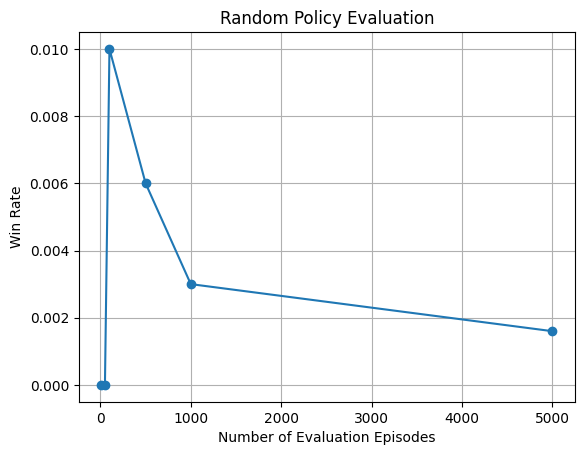

In [9]:
episode_counts = [10, 50, 100, 500, 1000, 5000]
win_rates = []

for n in episode_counts:
    w, _ = evaluate_policy(env, lambda s: env.action_space.sample(), n_episodes=n)
    win_rates.append(w)

plt.plot(episode_counts, win_rates, marker='o')
plt.xlabel("Number of Evaluation Episodes")
plt.ylabel("Win Rate")
plt.title("Random Policy Evaluation")
plt.grid(True)
plt.show()

ANSWER 2 :
With a small number of episodes, the estimated win rate fluctuates significantly due to randomness. As the number of evaluation episodes increases, the estimate becomes more stable. Around 1000 episodes or more generally provides a reliable estimate.

In [8]:
safe_policy = [
    1, 2, 1, 0,
    2, 0, 2, 0,
    2, 1, 1, 0,
    0, 2, 2, 0,
]

slip_win, slip_ret = evaluate_policy(
    env_slip,
    lambda s: safe_policy[s]
)

print(f"Safe policy win rate: {slip_win:.2%}")
print(f"Average return: {slip_ret:.3f}")

Safe policy win rate: 3.50%
Average return: 0.035


ANSWER 3 :A systematic policy that avoids dangerous edges performs better than a completely random policy on the slippery lake. However, because movement is stochastic, the agent can still slip into holes, so the policy cannot guarantee success.